In [1]:
import os
import json
import numpy as np
import pandas as pd
import torchxrayvision as xrv
import torch
import torchvision.models as models
import torch.nn as nn
import torch
from tqdm import tqdm
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_score, recall_score, average_precision_score, 
    matthews_corrcoef, brier_score_loss, precision_recall_curve
)

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from util.PNGDatasetNormalized import PNGFolderDataset

## Re-Usable Function

In [2]:
def safe_collate(batch):
    batch = [b for b in batch if b is not None]

    imgs = []
    labs = []

    for b in batch:
        img = torch.tensor(b["img"])
        lab = torch.tensor(b["lab"])

        # Ensure image is 3-channel
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)  # grayscale → RGB
        elif img.ndim == 2:
            img = img.unsqueeze(0).repeat(3, 1, 1)  # 2D → 3D RGB
        elif img.shape[0] == 3:
            pass  # already RGB
        else:
            raise ValueError(f"Unexpected image shape: {img.shape}")

        imgs.append(img)
        labs.append(lab)

    return {
        "img": torch.stack(imgs),
        "lab": torch.stack(labs),
        "idx": [b["idx"] for b in batch],
    }

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model_name, path):
    """Load the correct architecture (DenseNet121 or Swin-B) with 1 output."""
    
    if model_name == "SwinB-Weighted":
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, 1)

    elif model_name == "SwinB":
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, 1)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    checkpoint = torch.load(path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()
    return model

In [4]:
# ---- Inference Function ----
def run_inference(model, loader):
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference", leave=False):
            inputs = batch["img"].to(device)
            labels = batch["lab"].cpu().numpy()
            labels = np.nan_to_num(labels, nan=0.0).astype(int)

            outputs = model(inputs).squeeze(1)
            outputs = torch.clamp(outputs, min=-20, max=20)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_probs, all_preds, all_labels

# ---- Helper to calculate Mean ± Std ----
def get_stats(values):
    clean_vals = [v for v in values if not np.isnan(v)]
    if len(clean_vals) == 0:
        return 0.0, 0.0
    return np.mean(clean_vals), np.std(clean_vals)

In [5]:
# ---- Helper to find Optimal F1 Threshold ----
def get_optimal_f1_threshold(y_true, y_probs):
    """Finds the threshold that maximizes F1 score using Precision-Recall Curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 for all thresholds (add epsilon to avoid /0)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    
    # Handle edge case where best_idx is the last element
    if best_idx < len(thresholds):
        best_thresh = thresholds[best_idx]
    else:
        best_thresh = thresholds[-1]
        
    return best_thresh, f1_scores[best_idx]

# ---- Bootstrapping Logic ----
def compute_bootstrap_stats(labels, preds, probs, n_bootstraps=1000):
    boot_stats = {
        "accuracy": [], "f1": [], "precision": [], "recall": [], 
        "mcc": [], "roc_auc": [], "auprc": [], "brier_score": []
    }

    for _ in range(n_bootstraps):
        indices = resample(np.arange(len(labels)), replace=True)
        bs_probs = probs[indices]
        bs_preds = preds[indices]
        bs_labels = labels[indices]
        
        boot_stats["accuracy"].append(accuracy_score(bs_labels, bs_preds))
        boot_stats["precision"].append(precision_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["recall"].append(recall_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["f1"].append(f1_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["mcc"].append(matthews_corrcoef(bs_labels, bs_preds))
        boot_stats["brier_score"].append(brier_score_loss(bs_labels, bs_probs))

        try:
            if len(np.unique(bs_labels)) > 1:
                boot_stats["roc_auc"].append(roc_auc_score(bs_labels, bs_probs))
                boot_stats["auprc"].append(average_precision_score(bs_labels, bs_probs))
            else:
                boot_stats["roc_auc"].append(np.nan)
                boot_stats["auprc"].append(np.nan)
        except ValueError:
            boot_stats["roc_auc"].append(np.nan)
            boot_stats["auprc"].append(np.nan)

    final_metrics = {}
    
    for metric_name, values in boot_stats.items():
        clean_vals = [v for v in values if not np.isnan(v)]
        if not clean_vals: 
            mean_val, std_val = 0.0, 0.0
        else:
            mean_val, std_val = np.mean(clean_vals), np.std(clean_vals)
            
        final_metrics[f"{metric_name}_mean"] = mean_val
        final_metrics[f"{metric_name}_std"] = std_val

    return final_metrics

In [6]:
class XRVCorrectionDataset(torch.utils.data.Dataset):
    """
    Wraps standard XRV datasets (range -1024 to 1024) and 
    rescales them to [0, 1] to match PNGFolderDataset.
    Exposes essential attributes for MergeDataset.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        if hasattr(dataset, 'csv'): self.csv = dataset.csv
        if hasattr(dataset, 'pathologies'): self.pathologies = dataset.pathologies
        if hasattr(dataset, 'labels'): self.labels = dataset.labels 
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['img']
        # Rescale [-1024, 1024] -> [0, 1]
        img = (img + 1024) / 2048.0
        img = np.clip(img, 0, 1)
        if img.ndim == 2: img = np.expand_dims(img, 0)
        sample['img'] = img
        return sample

 # BRAX Dataset Handling

In [8]:
import pandas as pd

brax_csv = r"/home/varrel/GitHub/CXR-Analysis/data/brax_master_spreadsheet_update.csv"
brax_df = pd.read_csv(brax_csv)
brax_df['PngPath'] = brax_df['PngPath'].str.split('/').str[-1]
brax_df['PngPath'] = brax_df['PngPath'].str.replace('.png', '', regex=False)
brax_filtered = brax_df[brax_df['ViewPosition'].isin(['PA', 'AP'])]
brax_split = brax_filtered[['PngPath', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']]

brax_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split.csv", index=False)

In [55]:
brax_csv = r"/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split.csv"
brax_df = pd.read_csv(brax_csv)
brax_zeroes = brax_df.fillna(0)
brax_ones = brax_df.fillna(1)

# Creating U-Ignore
brax_atelectasis = brax_df.dropna(subset=['Atelectasis'])
brax_atelectasis = brax_atelectasis[brax_atelectasis['Atelectasis'] != -1]
print(len(brax_atelectasis))

brax_cardiomegaly = brax_df.dropna(subset=['Cardiomegaly'])
brax_cardiomegaly = brax_cardiomegaly[brax_cardiomegaly['Cardiomegaly'] != -1]
print(len(brax_cardiomegaly))

brax_consolidation = brax_df.dropna(subset=['Consolidation'])
brax_consolidation = brax_consolidation[brax_consolidation['Consolidation'] != -1]
print(len(brax_consolidation))

brax_edema = brax_df.dropna(subset=['Edema'])
brax_edema = brax_edema[brax_edema['Edema'] != -1]
print(len(brax_edema))

brax_enlarged = brax_df.dropna(subset=['Enlarged Cardiomediastinum'])
brax_enlarged = brax_enlarged[brax_enlarged['Enlarged Cardiomediastinum'] != -1]
print(len(brax_enlarged))

brax_fracture = brax_df.dropna(subset=['Fracture'])
brax_fracture = brax_fracture[brax_fracture['Fracture'] != -1]
print(len(brax_fracture))

brax_lung_lesion = brax_df.dropna(subset=['Lung Lesion'])
brax_lung_lesion = brax_lung_lesion[brax_lung_lesion['Lung Lesion'] != -1]
print(len(brax_lung_lesion))

brax_lung_opacity = brax_df.dropna(subset=['Lung Opacity'])
brax_lung_opacity = brax_lung_opacity[brax_lung_opacity['Lung Opacity'] != -1]
print(len(brax_lung_opacity))

brax_pleural_effusion = brax_df.dropna(subset=['Pleural Effusion'])
brax_pleural_effusion = brax_pleural_effusion[brax_pleural_effusion['Pleural Effusion'] != -1]
print(len(brax_pleural_effusion))

brax_pneumonia = brax_df.dropna(subset=['Pneumonia'])
brax_pneumonia = brax_pneumonia[brax_pneumonia['Pneumonia'] != -1]
print(len(brax_pneumonia))

brax_pneumothorax = brax_df.dropna(subset=['Pneumothorax'])
brax_pneumothorax = brax_pneumothorax[brax_pneumothorax['Pneumothorax'] != -1]
print(len(brax_pneumothorax))

brax_support_devices = brax_df.dropna(subset=['Support Devices'])
brax_support_devices = brax_support_devices[brax_support_devices['Support Devices'] != -1]
print(len(brax_support_devices))


brax_zeroes.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_zeroes.csv", index=False)
brax_ones.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ones.csv", index=False)
brax_atelectasis.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_atelectasis.csv", index=False)
brax_cardiomegaly.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_cardiomegaly.csv", index=False)
brax_consolidation.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_consolidation.csv", index=False)
brax_edema.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_edema.csv", index=False)
brax_enlarged.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_enlarged.csv", index=False)
brax_fracture.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_fracture.csv", index=False)
brax_lung_lesion.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_lesion.csv", index=False)
brax_lung_opacity.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_opacity.csv", index=False)
brax_pleural_effusion.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_effusion.csv", index=False)
brax_pneumonia.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_pneumonia.csv", index=False)
brax_pneumothorax.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_pneumothorax.csv", index=False)
brax_support_devices.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_supportdevices.csv", index=False)    

1273
13973
1127
9
11723
7727
572
1517
14490
285
83
5582


In [59]:
brax_atelectasis['Atelectasis'].value_counts()

Atelectasis
1.0    1255
0.0      18
Name: count, dtype: int64

# Atelectasis

In [57]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_atelectasis_model_epoch6.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [27]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Atelectasis']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Cardiomegaly'), np.str_('Enlarged Cardiomediastinum'), np.str_('Lung Lesion'), np.str_('Pleural Other'), np.str_('Fracture'), np.str_('Lung Opacity'), np.str_('Effusion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Consolidation')} will be dropped
{np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Cardiomegaly'), np.str_('Enlarged Cardiomediastinum'), np.str_('Lung Lesion'), np.str_('Pleural Other'), np.str_('Fracture'), np.str_('Lung Opacity'), np.str_('Effusion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Consolidation')} will be dropped
{'Nodule', 'Pneumothorax', 'Edema', 'Hernia', 'Cardiomegaly', 'Emphysema', 'Fibrosis', 'Mass', 'Effusion', 'Infiltration', 'Pneumonia', 'Consolidation', 'Pleural_Thickening'} will be dropped
{'Nodule', 'Pneumothorax', 'Edema', 'Hernia', 'Cardiomegaly', 'Emphysema', 'Fibrosis', 'Mass', 'Effusion', 'Infiltration', 'Pneumonia', 'Consolidation', 'Pleural_Thickening'} 

### Train

In [28]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9142 ± 0.0004
  AUPRC:     0.8282 ± 0.0009

[OPTIMAL Threshold 0.5561] Results:
  MCC:       0.6348 ± 0.0012
  F1:        0.7357 ± 0.0009
  AUC-ROC:   0.9142 ± 0.0004


### Selection

In [29]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8963 ± 0.0014
  AUPRC:     0.7959 ± 0.0027

[OPTIMAL Threshold 0.5683] Results:
  MCC:       0.5962 ± 0.0036
  F1:        0.7070 ± 0.0028
  AUC-ROC:   0.8963 ± 0.0014


### Test On-Hold Dataset

In [33]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Atelectasis']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Cardiomegaly'), np.str_('Enlarged Cardiomediastinum'), np.str_('Lung Lesion'), np.str_('Pleural Other'), np.str_('Fracture'), np.str_('Lung Opacity'), np.str_('Effusion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Consolidation')} will be dropped
{'Nodule', 'Pneumothorax', 'Edema', 'Hernia', 'Cardiomegaly', 'Emphysema', 'Fibrosis', 'Mass', 'Effusion', 'Infiltration', 'Pneumonia', 'Consolidation', 'Pleural_Thickening'} will be dropped
{np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Cardiomegaly'), np.str_('Enlarged Cardiomediastinum'), np.str_('Lung Lesion'), np.str_('Pleural Other'), np.str_('Fracture'), np.str_('Lung Opacity'), np.str_('Effusion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Consolidation')} will be dropped
{'Pneumothorax', 'Edema', 'Support Devices', 'Cardiomegaly', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'No Finding', 'Enlarged Cardio.', 'Pneumonia', 'Pleural Effusion', 'Con

In [34]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8928 ± 0.0013
  AUPRC:     0.7816 ± 0.0028

[OPTIMAL Threshold 0.5501] Results:
  MCC:       0.5777 ± 0.0033
  F1:        0.6913 ± 0.0026
  AUC-ROC:   0.8928 ± 0.0013


### BRAX Dataset

In [58]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_atelectasis.csv",
    id_col="PngPath"
)

classes = ['Atelectasis']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.5728 ± 0.0580
  AUPRC:     0.9901 ± 0.0031

[OPTIMAL Threshold 0.0037] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9929 ± 0.0017
  AUC-ROC:   0.5765 ± 0.0575


In [61]:
brax_test.csv['Atelectasis'].value_counts()

Atelectasis
1.0    1255
0.0      18
Name: count, dtype: int64

# Cardiomegaly

In [62]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_cardiomegaly_model_epoch5.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [13]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Cardiomegaly']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will

### Train

In [14]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9312 ± 0.0004
  AUPRC:     0.8395 ± 0.0009

[OPTIMAL Threshold 0.5932] Results:
  MCC:       0.6619 ± 0.0012
  F1:        0.7516 ± 0.0009
  AUC-ROC:   0.9312 ± 0.0004


### Selection

In [15]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9175 ± 0.0011
  AUPRC:     0.8094 ± 0.0028

[OPTIMAL Threshold 0.5867] Results:
  MCC:       0.6239 ± 0.0035
  F1:        0.7228 ± 0.0027
  AUC-ROC:   0.9175 ± 0.0011


### Test On-Hold Dataset

In [16]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Cardiomegaly']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Consolidation', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Edema', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Lung 

In [17]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9109 ± 0.0011
  AUPRC:     0.7949 ± 0.0029

[OPTIMAL Threshold 0.5538] Results:
  MCC:       0.6034 ± 0.0032
  F1:        0.7102 ± 0.0024
  AUC-ROC:   0.9109 ± 0.0011


### BRAX Dataset

In [63]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_cardiomegaly.csv",
    id_col="PngPath"
)

classes = ['Cardiomegaly']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9488 ± 0.0025
  AUPRC:     0.7278 ± 0.0111

[OPTIMAL Threshold 0.0424] Results:
  MCC:       0.6230 ± 0.0102
  F1:        0.6641 ± 0.0093
  AUC-ROC:   0.9489 ± 0.0024


In [64]:
brax_test.csv['Cardiomegaly'].value_counts()

Cardiomegaly
0.0    12480
1.0     1492
Name: count, dtype: int64

# Consolidation

In [65]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_consolidation_model_epoch4.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [20]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Consolidation']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be 

### Train

In [21]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9497 ± 0.0004
  AUPRC:     0.8411 ± 0.0011

[OPTIMAL Threshold 0.7965] Results:
  MCC:       0.7352 ± 0.0012
  F1:        0.7796 ± 0.0011
  AUC-ROC:   0.9497 ± 0.0004


### Selection

In [22]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9396 ± 0.0012
  AUPRC:     0.8106 ± 0.0036

[OPTIMAL Threshold 0.7602] Results:
  MCC:       0.7113 ± 0.0037
  F1:        0.7587 ± 0.0032
  AUC-ROC:   0.9396 ± 0.0012


### Test On-Hold Dataset

In [23]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Consolidation']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{np.str_('Lung Opacity'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Edema', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Lung Lesi

In [24]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9347 ± 0.0012
  AUPRC:     0.7993 ± 0.0033

[OPTIMAL Threshold 0.7650] Results:
  MCC:       0.6953 ± 0.0037
  F1:        0.7434 ± 0.0032
  AUC-ROC:   0.9347 ± 0.0012


### BRAX Dataset

In [66]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_consolidation.csv",
    id_col="PngPath"
)

classes = ['Consolidation']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.5601 ± 0.1254
  AUPRC:     0.9926 ± 0.0047

[OPTIMAL Threshold 0.0003] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9969 ± 0.0012
  AUC-ROC:   0.5687 ± 0.1201


In [67]:
brax_test.csv['Consolidation'].value_counts()

Consolidation
1.0    1120
0.0       7
Name: count, dtype: int64

# Edema

In [68]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_edema_model_epoch4.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [27]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Edema']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Emphysema', 'Atelectasis', 'Pleural_T

### Train

In [28]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9500 ± 0.0003
  AUPRC:     0.8182 ± 0.0012

[OPTIMAL Threshold 0.6479] Results:
  MCC:       0.6864 ± 0.0013
  F1:        0.7443 ± 0.0011
  AUC-ROC:   0.9500 ± 0.0003


### Selection

In [29]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9399 ± 0.0010
  AUPRC:     0.7880 ± 0.0035

[OPTIMAL Threshold 0.6589] Results:
  MCC:       0.6485 ± 0.0036
  F1:        0.7118 ± 0.0031
  AUC-ROC:   0.9399 ± 0.0010


### Test On-Hold Dataset

In [33]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Edema']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Consolidation', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Pneumonia', 'Atelecta

In [34]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9361 ± 0.0010
  AUPRC:     0.7782 ± 0.0035

[OPTIMAL Threshold 0.6689] Results:
  MCC:       0.6323 ± 0.0037
  F1:        0.6996 ± 0.0032
  AUC-ROC:   0.9361 ± 0.0010


### BRAX Dataset

In [69]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_edema.csv",
    id_col="PngPath"
)

classes = ['Edema']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====


Inference:   0%|          | 0/1 [00:00<?, ?it/s]


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.0000 ± 0.0000
  AUPRC:     0.0000 ± 0.0000

[OPTIMAL Threshold 0.0001] Results:
  MCC:       0.0000 ± 0.0000
  F1:        1.0000 ± 0.0000
  AUC-ROC:   0.0000 ± 0.0000


In [70]:
brax_test.csv['Edema'].value_counts()

Edema
1.0    9
Name: count, dtype: int64

# Enlarged

In [72]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_enlarged_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [38]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Enlarged Cardiomediastinum']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
pc_png_train.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in pc_png_train.pathologies
]
openi_png_train.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in openi_png_train.pathologies
]
pc_png_selection.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in pc_png_selection.pathologies
]
openi_png_selection.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in openi_png_selection.pathologies
]
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_chex_train, d_mimic_train, pc_png_train, openi_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support D

### Train

In [39]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9636 ± 0.0003
  AUPRC:     0.9330 ± 0.0006

[OPTIMAL Threshold 0.7096] Results:
  MCC:       0.8223 ± 0.0010
  F1:        0.8697 ± 0.0007
  AUC-ROC:   0.9636 ± 0.0003


### Selection

In [40]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9531 ± 0.0010
  AUPRC:     0.9079 ± 0.0019

[OPTIMAL Threshold 0.7566] Results:
  MCC:       0.7810 ± 0.0029
  F1:        0.8361 ± 0.0023
  AUC-ROC:   0.9531 ± 0.0010


### Test On-Hold Dataset

In [41]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Enlarged Cardiomediastinum']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
pc_png_test.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in pc_png_test.pathologies
]
openi_png_test.pathologies = [
    "Enlarged Cardiomediastinum" if p == "Enlarged Cardio." else p
    for p in openi_png_test.pathologies
]
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_chex_test, d_mimic_test, pc_png_test, openi_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Consolidation', 'Lung Lesion', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Atelectasis', 'Pneumothorax'} will be dropped
{'Lung Opacity', 'Consolidation', 'Lung Lesion', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Atelectasis', 'Pneumothorax'} will be droppe

In [42]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9503 ± 0.0011
  AUPRC:     0.9014 ± 0.0020

[OPTIMAL Threshold 0.6909] Results:
  MCC:       0.7748 ± 0.0030
  F1:        0.8306 ± 0.0023
  AUC-ROC:   0.9503 ± 0.0011


### BRAX Dataset

In [73]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_enlarged.csv",
    id_col="PngPath"
)

classes = ['Enlarged Cardiomediastinum']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8678 ± 0.0421
  AUPRC:     0.0310 ± 0.0132

[OPTIMAL Threshold 0.6613] Results:
  MCC:       0.0874 ± 0.0420
  F1:        0.0769 ± 0.0363
  AUC-ROC:   0.8665 ± 0.0413


In [74]:
brax_test.csv['Enlarged Cardiomediastinum'].value_counts()

Enlarged Cardiomediastinum
0.0    11698
1.0       24
Name: count, dtype: int64

# Fracture

In [75]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_fracture_model_epoch1.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [50]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Fracture']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Conso

### Train

In [51]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8710 ± 0.0010
  AUPRC:     0.5355 ± 0.0027

[OPTIMAL Threshold 0.7781] Results:
  MCC:       0.4984 ± 0.0021
  F1:        0.5477 ± 0.0020
  AUC-ROC:   0.8710 ± 0.0011


### Selection

In [52]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8584 ± 0.0029
  AUPRC:     0.4881 ± 0.0070

[OPTIMAL Threshold 0.7473] Results:
  MCC:       0.4625 ± 0.0060
  F1:        0.5127 ± 0.0056
  AUC-ROC:   0.8584 ± 0.0030


### Test On-Hold Dataset

In [54]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Fracture']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Consolidation', 'Support Devices', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Edema', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Lung Lesion'} will be dropped
{'Lung Opacity', 'Consolidation', 'Support Devices', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Edema', 'Pneumonia', 'Atelect

In [55]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8605 ± 0.0029
  AUPRC:     0.5054 ± 0.0076

[OPTIMAL Threshold 0.7821] Results:
  MCC:       0.4768 ± 0.0059
  F1:        0.5243 ± 0.0055
  AUC-ROC:   0.8607 ± 0.0029


### BRAX Dataset

In [76]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_fracture.csv",
    id_col="PngPath"
)

classes = ['Fracture']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.6669 ± 0.0175
  AUPRC:     0.0888 ± 0.0134

[OPTIMAL Threshold 0.0891] Results:
  MCC:       0.1293 ± 0.0172
  F1:        0.1530 ± 0.0148
  AUC-ROC:   0.6650 ± 0.0175


In [77]:
brax_test.csv['Fracture'].value_counts()

Fracture
0.0    7467
1.0     259
Name: count, dtype: int64

# Lung Lesion

In [78]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [58]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Lung Lesion']

"""---- Create Lung Lesion Label for NIH Dataset (Train) ---"""
# create NIH label (lung lesion) if not present
if "Lung Lesion" not in d_nih_train_raw.pathologies:
    d_nih_train_raw.pathologies.append("Lung Lesion")

mass_idx = d_nih_train_raw.pathologies.index("Mass")
nodule_idx = d_nih_train_raw.pathologies.index("Nodule")

# Original labels shape: (N, 14)
old_labels = d_nih_train_raw.labels
N, old_len = old_labels.shape
new_len = len(d_nih_train_raw.pathologies)

# Create new labels matrix with extra column
new_labels = np.zeros((N, new_len), dtype=old_labels.dtype)
new_labels[:, :old_len] = old_labels

# Fill Lung Lesion column as OR(Mass, Nodule)
lunglesion_idx = d_nih_train_raw.pathologies.index("Lung Lesion")
new_labels[:, lunglesion_idx] = np.logical_or(
    old_labels[:, mass_idx] == 1,
    old_labels[:, nodule_idx] == 1
).astype(int)

# Replace dataset labels
d_nih_train_raw.labels = new_labels

"""---- Create Lung Lesion Label for NIH Dataset (Selection) ---"""
# create NIH label (lung lesion) if not present
if "Lung Lesion" not in d_nih_sel_raw.pathologies:
    d_nih_sel_raw.pathologies.append("Lung Lesion")

mass_idx = d_nih_sel_raw.pathologies.index("Mass")
nodule_idx = d_nih_sel_raw.pathologies.index("Nodule")

# Original labels shape: (N, 14)
old_labels = d_nih_sel_raw.labels
N, old_len = old_labels.shape
new_len = len(d_nih_sel_raw.pathologies)

# Create new labels matrix with extra column
new_labels = np.zeros((N, new_len), dtype=old_labels.dtype)
new_labels[:, :old_len] = old_labels

# Fill Lung Lesion column as OR(Mass, Nodule)
lunglesion_idx = d_nih_sel_raw.pathologies.index("Lung Lesion")
new_labels[:, lunglesion_idx] = np.logical_or(
    old_labels[:, mass_idx] == 1,
    old_labels[:, nodule_idx] == 1
).astype(int)

# Replace dataset labels
d_nih_sel_raw.labels = new_labels

xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Ple

### Train

In [59]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8550 ± 0.0010
  AUPRC:     0.4797 ± 0.0028

[OPTIMAL Threshold 0.5807] Results:
  MCC:       0.4680 ± 0.0022
  F1:        0.5056 ± 0.0021
  AUC-ROC:   0.8550 ± 0.0010


### Selection

In [60]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8101 ± 0.0033
  AUPRC:     0.3716 ± 0.0071

[OPTIMAL Threshold 0.2129] Results:
  MCC:       0.3698 ± 0.0061
  F1:        0.4203 ± 0.0058
  AUC-ROC:   0.8101 ± 0.0032


### Test On-Hold Dataset

In [61]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Lung Lesion']

"""---- Create Lung Lesion Label for NIH Dataset (Test) ---"""
# create NIH label (lung lesion) if not present
if "Lung Lesion" not in d_nih_test_raw.pathologies:
    d_nih_test_raw.pathologies.append("Lung Lesion")

mass_idx = d_nih_test_raw.pathologies.index("Mass")
nodule_idx = d_nih_test_raw.pathologies.index("Nodule")

# Original labels shape: (N, 14)
old_labels = d_nih_test_raw.labels
N, old_len = old_labels.shape
new_len = len(d_nih_test_raw.pathologies)

# Create new labels matrix with extra column
new_labels = np.zeros((N, new_len), dtype=old_labels.dtype)
new_labels[:, :old_len] = old_labels

# Fill Lung Lesion column as OR(Mass, Nodule)
lunglesion_idx = d_nih_test_raw.pathologies.index("Lung Lesion")
new_labels[:, lunglesion_idx] = np.logical_or(
    old_labels[:, mass_idx] == 1,
    old_labels[:, nodule_idx] == 1
).astype(int)

# Replace dataset labels
d_nih_test_raw.labels = new_labels

xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Infiltration', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{np.str_('Lung Opacity'), np.str_('Consolidation'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Lung Opacity', 'Consolidation', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Edema', 'Pneumonia', 'At

In [62]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8047 ± 0.0032
  AUPRC:     0.3616 ± 0.0068

[OPTIMAL Threshold 0.1818] Results:
  MCC:       0.3616 ± 0.0059
  F1:        0.4144 ± 0.0056
  AUC-ROC:   0.8048 ± 0.0033


### BRAX Dataset

In [79]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_lesion.csv",
    id_col="PngPath"
)

classes = ['Lung Lesion']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.4643 ± 0.0768
  AUPRC:     0.9609 ± 0.0131

[OPTIMAL Threshold 0.0019] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9842 ± 0.0037
  AUC-ROC:   0.4642 ± 0.0743


In [80]:
brax_test.csv['Lung Lesion'].value_counts()

Lung Lesion
1.0    554
0.0     18
Name: count, dtype: int64

# Lung Opacity

In [82]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [68]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Lung Opacity']
d_nih_train_raw.pathologies = [
    "Lung Opacity" if p == "Infiltration" else p
    for p in d_nih_train_raw.pathologies
]
d_nih_sel_raw.pathologies = [
    "Lung Opacity" if p == "Infiltration" else p
    for p in d_nih_sel_raw.pathologies
]
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{'Consolidation', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will

### Train

In [69]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9042 ± 0.0004
  AUPRC:     0.8627 ± 0.0006

[OPTIMAL Threshold 0.5033] Results:
  MCC:       0.6330 ± 0.0011
  F1:        0.7558 ± 0.0008
  AUC-ROC:   0.9042 ± 0.0004


### Selection

In [70]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8850 ± 0.0013
  AUPRC:     0.8367 ± 0.0020

[OPTIMAL Threshold 0.5303] Results:
  MCC:       0.5971 ± 0.0032
  F1:        0.7258 ± 0.0024
  AUC-ROC:   0.8849 ± 0.0014


### Test On-Hold Dataset

In [71]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Lung Opacity']
d_nih_test_raw.pathologies = [
    "Lung Opacity" if p == "Infiltration" else p
    for p in d_nih_test_raw.pathologies
]
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Mass', 'Fibrosis', 'Hernia', 'Pneumothorax', 'Nodule', 'Pneumonia', 'Cardiomegaly', 'Edema', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Effusion'} will be dropped
{np.str_('Consolidation'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Cardiomegaly'), np.str_('Edema'), np.str_('Pleural Other'), np.str_('Atelectasis'), np.str_('Pneumothorax'), np.str_('Enlarged Cardiomediastinum'), np.str_('Effusion')} will be dropped
{'Consolidation', 'Support Devices', 'Fracture', 'Pleural Effusion', 'No Finding', 'Enlarged Cardio.', 'Cardiomegaly', 'Edema', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Lung 

In [72]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8755 ± 0.0013
  AUPRC:     0.8243 ± 0.0020

[OPTIMAL Threshold 0.4826] Results:
  MCC:       0.5687 ± 0.0032
  F1:        0.7130 ± 0.0023
  AUC-ROC:   0.8754 ± 0.0014


### BRAX Dataset

In [83]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_opacity.csv",
    id_col="PngPath"
)

classes = ['Lung Opacity']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====


Inference:   0%|          | 0/95 [00:00<?, ?it/s]


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.5213 ± 0.0631
  AUPRC:     0.9868 ± 0.0042

[OPTIMAL Threshold 0.0051] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9930 ± 0.0015
  AUC-ROC:   0.5184 ± 0.0605


In [84]:
brax_test.csv['Lung Opacity'].value_counts()

Lung Opacity
1.0    1496
0.0      21
Name: count, dtype: int64

# Pleural Effusion

In [85]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_effusion_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [8]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pleural Effusion']
d_mimic_train_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_mimic_train_raw.pathologies
]
d_chex_train_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_chex_train_raw.pathologies
]
d_nih_train_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_nih_train_raw.pathologies
]
d_mimic_sel_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_mimic_sel_raw.pathologies
]
d_chex_sel_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_chex_sel_raw.pathologies
]
d_nih_sel_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_nih_sel_raw.pathologies
]
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Cardiomegaly', 'Fibrosis'} will be dropped
{'Nodule', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Cardiomegaly', 

### Train

In [76]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9420 ± 0.0003
  AUPRC:     0.8448 ± 0.0010

[OPTIMAL Threshold 0.6130] Results:
  MCC:       0.7055 ± 0.0011
  F1:        0.7826 ± 0.0009
  AUC-ROC:   0.9420 ± 0.0003


### Selection

In [9]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9254 ± 0.0010
  AUPRC:     0.8048 ± 0.0029

[OPTIMAL Threshold 0.6081] Results:
  MCC:       0.6528 ± 0.0032
  F1:        0.7442 ± 0.0025
  AUC-ROC:   0.9254 ± 0.0011


### Test On-Hold Dataset

In [10]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pleural Effusion']
d_mimic_test_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_mimic_test_raw.pathologies
]
d_chex_test_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_chex_test_raw.pathologies
]
d_nih_test_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_nih_test_raw.pathologies
]
d_mimic_test_raw.pathologies = [
    "Pleural Effusion" if p == "Effusion" else p
    for p in d_mimic_test_raw.pathologies
]
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Cardiomegaly', 'Fibrosis'} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Lung Lesion', 'Consolidation', 'No Finding', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardio.', 'Fracture', 'S

In [11]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9212 ± 0.0011
  AUPRC:     0.8023 ± 0.0029

[OPTIMAL Threshold 0.5675] Results:
  MCC:       0.6460 ± 0.0032
  F1:        0.7397 ± 0.0025
  AUC-ROC:   0.9212 ± 0.0011


### BRAX Dataset

In [86]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_effusion.csv",
    id_col="PngPath"
)

classes = ['Pleural Effusion']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9320 ± 0.0062
  AUPRC:     0.6351 ± 0.0196

[OPTIMAL Threshold 0.1284] Results:
  MCC:       0.5855 ± 0.0177
  F1:        0.6002 ± 0.0172
  AUC-ROC:   0.9324 ± 0.0061


In [87]:
brax_test.csv['Pleural Effusion'].value_counts()

Pleural Effusion
0.0    13957
1.0      532
Name: count, dtype: int64

# Pneumonia

In [88]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [14]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)
d_rsna_train_raw = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/imaging/all_images/RSNA_dataset/stage_2_train_images_jpg/preprocess7",
                                                   csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/rsna_train_split_xrv.csv",
                                                   views=["PA","AP"])
d_rsna_sel_raw = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/imaging/all_images/RSNA_dataset/stage_2_train_images_jpg/preprocess7",
                                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/rsna_selection_split_xrv.csv",
                                                       views=["PA","AP"])

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pneumonia']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)
xrv.datasets.relabel_dataset(classes, d_rsna_train_raw)
xrv.datasets.relabel_dataset(classes, d_rsna_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)
d_rsna_train = XRVCorrectionDataset(d_rsna_train_raw)
d_rsna_selection = XRVCorrectionDataset(d_rsna_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)
pp_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PP_dataset/images_all/Pediatric Chest X-ray Pneumonia/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pp_train_split.csv",
    id_col="image_id"
)
pp_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PP_dataset/images_all/Pediatric Chest X-ray Pneumonia/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pp_selection_split.csv",
    id_col="image_id"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)
xrv.datasets.relabel_dataset(classes, pp_png_train)
xrv.datasets.relabel_dataset(classes, pp_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, d_rsna_train, pc_png_train, openi_png_train, vindr_png_train, pp_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, d_rsna_selection, pc_png_selection, openi_png_selection, vindr_png_selection, pp_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fibrosis'} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fib

### Train

In [15]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8693 ± 0.0007
  AUPRC:     0.5723 ± 0.0019

[OPTIMAL Threshold 0.6160] Results:
  MCC:       0.4856 ± 0.0018
  F1:        0.5405 ± 0.0017
  AUC-ROC:   0.8693 ± 0.0008


### Selection

In [16]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8487 ± 0.0023
  AUPRC:     0.5064 ± 0.0063

[OPTIMAL Threshold 0.5144] Results:
  MCC:       0.4372 ± 0.0052
  F1:        0.5007 ± 0.0048
  AUC-ROC:   0.8486 ± 0.0023


### Test On-Hold Dataset

In [19]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_rsna_test_raw = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/test_images/RSNA_dataset/images_all/preprocess7",
                                                   csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/rsna_test_split_xrv.csv",
                                                   views=["PA","AP"])

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pneumonia']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)
xrv.datasets.relabel_dataset(classes, d_rsna_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)
d_rsna_test = XRVCorrectionDataset(d_rsna_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)
pp_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/PP_dataset/images_all/test/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pp_test_split.csv",
    id_col="image_id"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)
xrv.datasets.relabel_dataset(classes, pp_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, d_rsna_test, pc_png_test, openi_png_test, vindr_png_test, pp_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fibrosis'} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Lung Opacity'} will be dropped
{'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'No Finding', 'Edema', 'Lung Opacity', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly

In [20]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8277 ± 0.0023
  AUPRC:     0.4679 ± 0.0058

[OPTIMAL Threshold 0.5138] Results:
  MCC:       0.3937 ± 0.0051
  F1:        0.4631 ± 0.0047
  AUC-ROC:   0.8278 ± 0.0024


### BRAX Dataset

In [89]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_pneumonia.csv",
    id_col="PngPath"
)

classes = ['Pneumonia']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.5645 ± 0.0542
  AUPRC:     0.9489 ± 0.0139

[OPTIMAL Threshold 0.0033] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9624 ± 0.0082
  AUC-ROC:   0.5645 ± 0.0548


In [90]:
brax_test.csv['Pneumonia'].value_counts()

Pneumonia
1.0    264
0.0     21
Name: count, dtype: int64

# Pneumothorax

In [91]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_pneumothorax_model_epoch9.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [23]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

d_nih_train_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_nih_sel_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_selection_split_xrv.csv",
                                     views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pneumothorax']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_nih_train_raw)
xrv.datasets.relabel_dataset(classes, d_nih_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_nih_train = XRVCorrectionDataset(d_nih_train_raw)
d_nih_selection = XRVCorrectionDataset(d_nih_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv",
    id_col="image_id"
)
vindr_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv",
    id_col="image_id"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)
siim_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/SIIM_dataset/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/siim_train_split.csv",
    id_col="ImageId"
)
siim_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/SIIM_dataset/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/siim_selection_split.csv",
    id_col="ImageId"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, vindr_png_train)
xrv.datasets.relabel_dataset(classes, vindr_png_selection)
xrv.datasets.relabel_dataset(classes, siim_png_train)
xrv.datasets.relabel_dataset(classes, siim_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_nih_train, d_chex_train, d_mimic_train, pc_png_train, openi_png_train, vindr_png_train, siim_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_nih_selection, d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, vindr_png_selection, siim_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fibrosis'} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fibrosis'} will

### Train

In [24]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9291 ± 0.0008
  AUPRC:     0.6615 ± 0.0028

[OPTIMAL Threshold 0.0374] Results:
  MCC:       0.6291 ± 0.0024
  F1:        0.6503 ± 0.0023
  AUC-ROC:   0.9290 ± 0.0008


### Selection

In [27]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8902 ± 0.0026
  AUPRC:     0.4730 ± 0.0085

[OPTIMAL Threshold 0.0322] Results:
  MCC:       0.4564 ± 0.0069
  F1:        0.4900 ± 0.0067
  AUC-ROC:   0.8901 ± 0.0026


### Test On-Hold Dataset

In [28]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_nih_test_raw = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Pneumothorax']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_nih_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_nih_test = XRVCorrectionDataset(d_nih_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
vindr_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/test_dataset/VinDr_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv",
    id_col="image_id"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)
siim_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/SIIM_dataset/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/siim_test_split.csv",
    id_col="ImageId"
)

# Relabel PNG Datasets
xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, vindr_png_test)
xrv.datasets.relabel_dataset(classes, siim_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_nih_test, d_chex_test, d_mimic_test, pc_png_test, openi_png_test, vindr_png_test, siim_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Nodule', 'Cardiomegaly', 'Consolidation', 'Edema', 'Emphysema', 'Pneumonia', 'Pleural_Thickening', 'Mass', 'Atelectasis', 'Infiltration', 'Hernia', 'Effusion', 'Fibrosis'} will be dropped
{np.str_('Support Devices'), np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'No Finding', 'Edema', 'Lung Opacity', 'Pneumonia', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardio.', 'Fracture', 'Support D

In [29]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8920 ± 0.0025
  AUPRC:     0.4614 ± 0.0086

[OPTIMAL Threshold 0.0368] Results:
  MCC:       0.4585 ± 0.0069
  F1:        0.4867 ± 0.0067
  AUC-ROC:   0.8919 ± 0.0026


### BRAX Dataset

In [92]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_pneumothorax.csv",
    id_col="PngPath"
)

classes = ['Pneumothorax']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Support Devices', 'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====


Inference:   0%|          | 0/6 [00:00<?, ?it/s]


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8051 ± 0.0487
  AUPRC:     0.8213 ± 0.0503

[OPTIMAL Threshold 0.0230] Results:
  MCC:       0.4631 ± 0.0792
  F1:        0.7355 ± 0.0490
  AUC-ROC:   0.8020 ± 0.0470


In [93]:
brax_test.csv['Pneumothorax'].value_counts()

Pneumothorax
0.0    45
1.0    38
Name: count, dtype: int64

# Support Device

In [94]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_supportdevice_model_epoch6.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [32]:
# 1. Load XRV Datasets
d_chex_train_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_train_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_chex_sel_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                       csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_selection_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)
d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Support Devices']
xrv.datasets.relabel_dataset(classes, d_chex_train_raw)
xrv.datasets.relabel_dataset(classes, d_chex_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_train = XRVCorrectionDataset(d_chex_train_raw)
d_chex_selection = XRVCorrectionDataset(d_chex_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_train_raw)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split_filtered.csv",
    id_col="ImageID"
)
pc_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv",
    id_col="ImageID"
)
openi_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split_filtered.csv",
    id_col="filename"
)
openi_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split_filtered.csv",
    id_col="filename"
)
ox_png_train = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/OX_dataset/ox_check/train/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/ox_train_split.csv",
    id_col="image_name"
)
ox_png_selection = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/OX_dataset/ox_check/train/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/ox_selection_split.csv",
    id_col="image_name"
)

# Relabel PNG Datasets
ox_png_train.pathologies = [
    "Support Devices" if p == "Support Device" else p
    for p in ox_png_train.pathologies
]
ox_png_selection.pathologies = [
    "Support Devices" if p == "Support Device" else p
    for p in ox_png_selection.pathologies
]
xrv.datasets.relabel_dataset(classes, openi_png_train)
xrv.datasets.relabel_dataset(classes, openi_png_selection)
xrv.datasets.relabel_dataset(classes, pc_png_train)
xrv.datasets.relabel_dataset(classes, pc_png_selection)
xrv.datasets.relabel_dataset(classes, ox_png_train)
xrv.datasets.relabel_dataset(classes, ox_png_selection)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_train = xrv.datasets.MergeDataset([d_chex_train, d_mimic_train, pc_png_train, openi_png_train, ox_png_train])
dmerge_selection = xrv.datasets.MergeDataset([d_chex_selection, d_mimic_selection, pc_png_selection, openi_png_selection, ox_png_selection])

train_loader = torch.utils.data.DataLoader(dmerge_train, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Training samples: {len(dmerge_train)}, Selection samples: {len(dmerge_selection)}")

{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('E

### Train

In [33]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, train_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9482 ± 0.0003
  AUPRC:     0.9090 ± 0.0006

[OPTIMAL Threshold 0.4385] Results:
  MCC:       0.7447 ± 0.0010
  F1:        0.8415 ± 0.0007
  AUC-ROC:   0.9482 ± 0.0003


### Selection

In [34]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, selection_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9395 ± 0.0009
  AUPRC:     0.8914 ± 0.0019

[OPTIMAL Threshold 0.3952] Results:
  MCC:       0.7152 ± 0.0030
  F1:        0.8198 ± 0.0020
  AUC-ROC:   0.9396 ± 0.0010


### Test On-Hold Dataset

In [39]:
# 1. Load XRV Datasets
d_chex_test_raw = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/train_chex_test_split_xrv.csv",
                                         views=["PA","AP"], unique_patients=False)
d_mimic_test_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                           csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_test_split_xrv.csv",
                                           metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                           views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Support Devices']
xrv.datasets.relabel_dataset(classes, d_chex_test_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_test_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_chex_test = XRVCorrectionDataset(d_chex_test_raw)
d_mimic_test = XRVCorrectionDataset(d_mimic_test_raw)

# 4. Load PNG Datasets (These are already [0, 1] from your new code)
pc_png_test = PNGFolderDataset(img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split_filtered.csv",
    id_col="ImageID"
)
openi_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/Openi_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split_filtered.csv",
    id_col="filename"
)
ox_png_test = PNGFolderDataset(img_dir="/home/varrel/test_images/OX_dataset/images_all/dev/train/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/ox_test_split.csv",
    id_col="image_name"
)

# Relabel PNG Datasets
ox_png_test.pathologies = [
    "Support Devices" if p == "Support Device" else p
    for p in ox_png_test.pathologies
]

xrv.datasets.relabel_dataset(classes, openi_png_test)
xrv.datasets.relabel_dataset(classes, pc_png_test)
xrv.datasets.relabel_dataset(classes, ox_png_test)

# 5. Merge (Now safe because EVERYTHING is [0, 1] numpy)
dmerge_test = xrv.datasets.MergeDataset([d_chex_test, d_mimic_test, pc_png_test, openi_png_test, ox_png_test])

test_loader = torch.utils.data.DataLoader(dmerge_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

print(f"Test samples: {len(dmerge_test)}")

{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{np.str_('Lung Lesion'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Atelectasis'), np.str_('Effusion'), np.str_('Pleural Other'), np.str_('Cardiomegaly'), np.str_('Fracture'), np.str_('Enlarged Cardiomediastinum')} will be dropped
{'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'No Finding', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardio.', 'Fracture'} will be dropped
{'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'No Finding', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardio.', 'F

In [40]:
results = {}
default_threshold = 0.5

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, test_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9338 ± 0.0010
  AUPRC:     0.8815 ± 0.0021

[OPTIMAL Threshold 0.3962] Results:
  MCC:       0.6994 ± 0.0029
  F1:        0.8106 ± 0.0020
  AUC-ROC:   0.9338 ± 0.0010


### BRAX Dataset

In [95]:
# U-Ignore Run
brax_test = PNGFolderDataset(img_dir="/home/varrel/imaging/brax/1.1.0/preprocess7/flat_png7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/brax_split_ignore_supportdevices.csv",
    id_col="PngPath"
)

classes = ['Support Devices']
xrv.datasets.relabel_dataset(classes, brax_test)
brax_loader = torch.utils.data.DataLoader(brax_test, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on BRAX Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, brax_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")

{'Lung Lesion', 'Pleural Effusion', 'Consolidation', 'Edema', 'Lung Opacity', 'Pneumonia', 'Pneumothorax', 'Atelectasis', 'Cardiomegaly', 'Fracture', 'Enlarged Cardiomediastinum'} will be dropped

===== Evaluating Model on BRAX Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.7462 ± 0.1026
  AUPRC:     0.9989 ± 0.0009

[OPTIMAL Threshold 0.0003] Results:
  MCC:       0.0000 ± 0.0000
  F1:        0.9992 ± 0.0003
  AUC-ROC:   0.7481 ± 0.0997


In [96]:
brax_test.csv['Support Devices'].value_counts()

Support Devices
1.0    5573
0.0       9
Name: count, dtype: int64

# Diagram

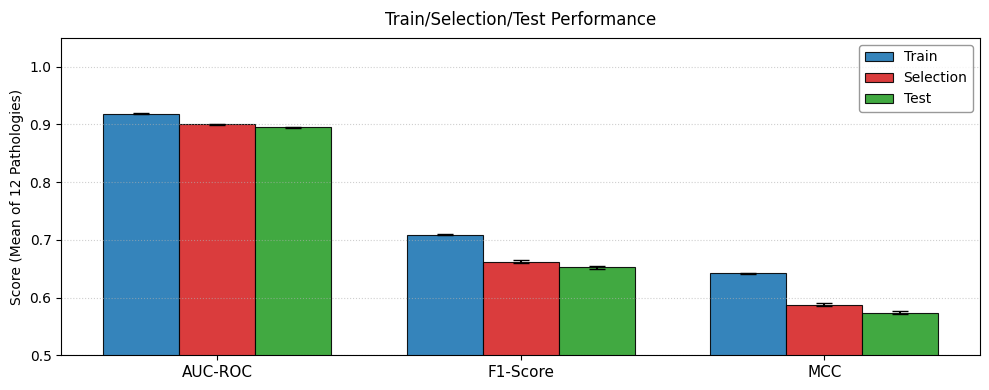

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Setup
metrics = ['AUC-ROC', 'F1-Score', 'MCC']
groups = ['Train', 'Selection', 'Test']

# Mean values (Example data showing close Val/Test performance)
means = {
    'Train': [0.91895, 0.70874, 0.64207],
    'Selection': [0.90029, 0.66249, 0.58765],
    'Test': [0.895033, 0.65224, 0.574016]
}

# Raw 95% CI Bounds (Lower Bound, Upper Bound)
# Format: [Lower_Val, Upper_Val]
ci_bounds = {
    'Train': [[0.91860, 0.91929], [0.707957, 0.70952], [0.64120, 0.64295]],
    'Selection': [[0.89923, 0.90135], [0.660245, 0.664738], [0.585141, 0.590176]],
    'Test': [[0.893968, 0.896098], [0.6500356, 0.6544477], [0.5715415, 0.5764918]]
}

# 2. Convert raw bounds to "Distance from Mean" for Matplotlib
def get_errors(group_name):
    lower_err = []
    upper_err = []
    for i, mean in enumerate(means[group_name]):
        low, high = ci_bounds[group_name][i]
        lower_err.append(mean - low)
        upper_err.append(high - mean)
    return [lower_err, upper_err]

# 3. Plotting Configuration
x = np.arange(len(metrics))
width = 0.25
colors = ['#1f77b4', '#d62728', "#2ca02c"]

fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# 4. Create Bars with Asymmetric Errors
for i, group in enumerate(groups):
    pos = x + (i - 1) * width
    y_err = get_errors(group) # Calculates the [lower_offset, upper_offset]
    
    ax.bar(pos, means[group], width, yerr=y_err, 
           label=group, capsize=6, color=colors[i], 
           edgecolor='black', linewidth=0.8, alpha=0.9)

# 5. Styling
ax.set_ylabel('Score (Mean of 12 Pathologies)', fontsize=10)
ax.set_title('Train/Selection/Test Performance', fontsize=12, pad=10)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05) # Caps at 1.05 for clean headroom
ax.legend(loc='upper right', frameon=True, shadow=False, fontsize=10, edgecolor='gray')
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("split_performance.png", dpi=300, bbox_inches='tight')
plt.show()

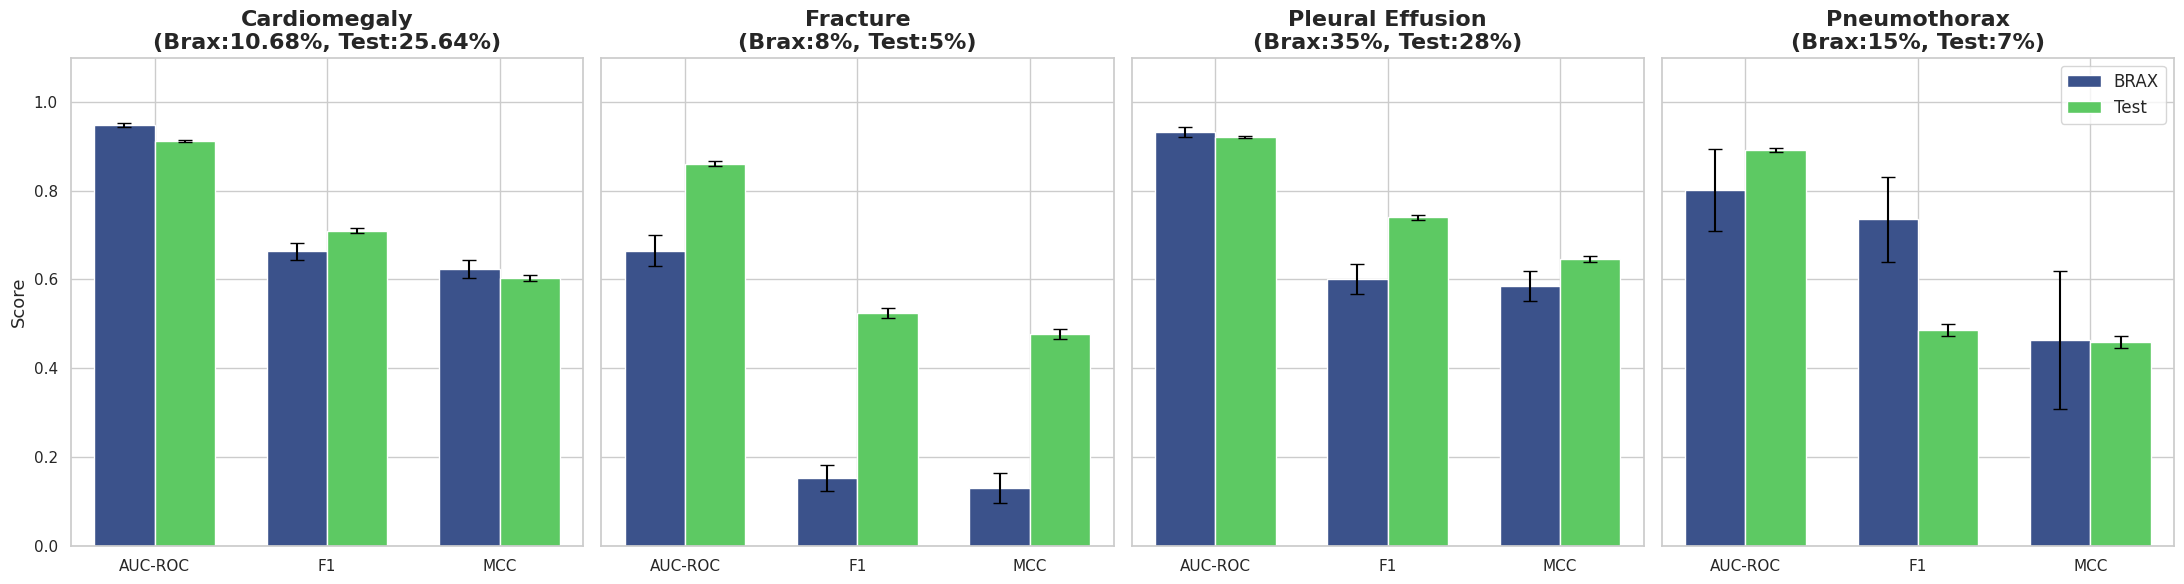

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. DATA (Unchanged)
pathologies = ['Cardiomegaly', 'Fracture', 'Pleural Effusion', 'Pneumothorax']
datasets = ['BRAX', 'Test']
metrics = ['AUC-ROC', 'F1', 'MCC']

prevalence = {
    'Cardiomegaly': {'BRAX': '10.68%', 'Test': '25.64%'},
    'Fracture': {'BRAX': '3.35%', 'Test': '8.68%'},
    'Pleural Effusion': {'BRAX': '3.67%', 'Test': '25.27%'},
    'Pneumothorax': {'BRAX': '15%', 'Test': '7%'}
}

results = {
    'Cardiomegaly': {
        'BRAX': {'AUC-ROC': (0.9489, 0.0047), 'F1': (0.6631, 0.0182), 'MCC': (0.6230, 0.0199)},
        'Test':  {'AUC-ROC': (0.9109, 0.0022), 'F1': (0.7102, 0.0047), 'MCC': (0.6034, 0.0063)}
    },
    'Fracture': {
        'BRAX': {'AUC-ROC': (0.6650, 0.0343), 'F1': (0.1530, 0.0290), 'MCC': (0.1293, 0.0337)},
        'Test':  {'AUC-ROC': (0.8607, 0.0057), 'F1': (0.5243, 0.0108), 'MCC': (0.4768, 0.0116)}
    },
    'Pleural Effusion': {
        'BRAX': {'AUC-ROC': (0.9324, 0.0119), 'F1': (0.6002, 0.0337), 'MCC': (0.5855, 0.0347)},
        'Test':  {'AUC-ROC': (0.9212, 0.0021), 'F1': (0.7397, 0.0049), 'MCC': (0.6460, 0.0063)}
    },
    'Pneumothorax': {
        'BRAX': {'AUC-ROC': (0.8020, 0.0921), 'F1': (0.7355, 0.0960), 'MCC': (0.4631, 0.1552)},
        'Test':  {'AUC-ROC': (0.8919, 0.0051), 'F1': (0.4867, 0.0131), 'MCC': (0.4585, 0.0135)}
    }
}

# 2. PLOTTING
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)

x = np.arange(len(metrics)) 
width = 0.35 

for i, path in enumerate(pathologies):
    brax_means = [results[path]['BRAX'][m][0] for m in metrics]
    brax_cis = [results[path]['BRAX'][m][1] for m in metrics]
    
    test_means = [results[path]['Test'][m][0] for m in metrics]
    test_cis = [results[path]['Test'][m][1] for m in metrics]
    
    # Plot bars
    axes[i].bar(x - width/2, brax_means, width, label='BRAX', color='#3b528b')
    axes[i].errorbar(x - width/2, brax_means, yerr=brax_cis, fmt='none', c='black', capsize=5)
    
    axes[i].bar(x + width/2, test_means, width, label='Test', color='#5dc963')
    axes[i].errorbar(x + width/2, test_means, yerr=test_cis, fmt='none', c='black', capsize=5)
    
    # Customizing the subplot
    prev_info = f"(Brax:{prevalence[path]['BRAX']}, Test:{prevalence[path]['Test']})"
    axes[i].set_title(f'{path}\n{prev_info}', fontsize=16, fontweight='bold')
    
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(metrics, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    
    # Y-axis label only on the first plot
    if i == 0:
        axes[i].set_ylabel('Score', fontsize=13)
    
    # Legend only on the 4th plot (Pneumothorax), top-right
    if i == 3:
        axes[i].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()